# 03 — Baselines and the model

**What this notebook establishes:** the two reference forecasts everything is
scored against, why the climatology is built the way it is, and an end-to-end
three-way comparison on one variable using the shipped code.

The climatology baseline is this study's contribution. Everything below imports
`forecasting.climatology` directly.

In [1]:
import marisviz as mv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mv.setup()

from forecasting.climatology import fit_climatology, apply_climatology
from forecasting.config import get_config
from forecasting.evaluator import compute_metrics, cross_validate
from forecasting.feature_engineering import TARGET, TARGET_ANCHOR, build_features
from forecasting.registry import resolve

config = get_config()
series = mv.load_series()
print("imported forecasting.climatology from backend/")

imported forecasting.climatology from backend/


## Baseline 1 — persistence

$$\hat{y}_{\text{pers}}(t+h) = y(t)$$

The last observed value. It needs no fitting, and on an autocorrelated
geophysical series it is a genuinely hard baseline — which is exactly why it
became the field's default reference.

It is also the **anchor** of the delta target from notebook 02, so a delta
model that outputs zero *is* persistence, exactly.

## Baseline 2 — climatology

For site $s$ and day of year $d$:

$$\hat{y}_{\text{clim}}(s,d) = \frac{1}{|W(d)|}\sum_{t\in W(d)} y_s(t),
\qquad W(d)=\{t : \delta(\mathrm{doy}(t), d) \le 15\}$$

where $\delta$ is *circular* day-of-year distance, so 31 December neighbours
1 January.

Three properties are load-bearing, and each is demonstrated below:
the **window**, the **circular mean**, and **where it is fitted**.

In [2]:
VARIABLE = "water_temperature"
panel = mv.target_panel(series, VARIABLE)
tidy = (panel.reset_index()
        .melt(id_vars="timestamp", var_name="site", value_name="value")
        .dropna(subset=["value"]))
coords = mv.load_sites().set_index("site")
tidy["latitude"] = tidy["site"].map(coords["latitude"])
tidy["longitude"] = tidy["site"].map(coords["longitude"])

fitted = fit_climatology(
    tidy["timestamp"], tidy["value"], tidy["site"],
    latitudes=tidy["latitude"], longitudes=tidy["longitude"],
    window_days=15,
)
print(f"fitted {fitted.locations} site climatologies, window +/-{fitted.window_days} d")

fitted 24 site climatologies, window +/-15 d


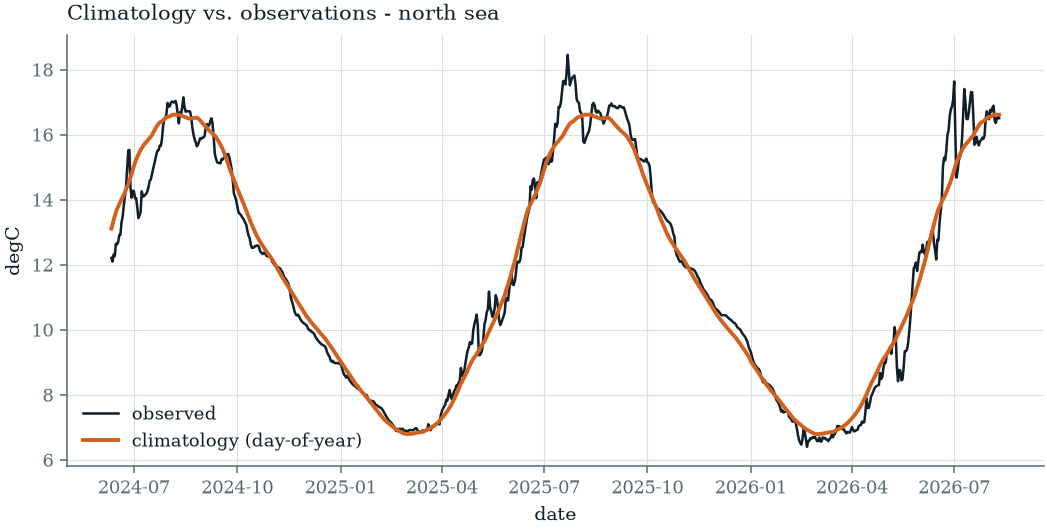

In [3]:
SHOW = "north_sea" if "north_sea" in panel.columns else panel.columns[0]
site_rows = tidy[tidy["site"] == SHOW]
predicted = apply_climatology(fitted, site_rows["timestamp"], site_rows["site"])

fig, ax = plt.subplots(figsize=(9, 4.0))
ax.plot(site_rows["timestamp"], site_rows["value"], color=mv.INK,
        linewidth=1.3, label="observed")
ax.plot(site_rows["timestamp"], predicted, color=mv.CLIMATOLOGY,
        linewidth=2.0, label="climatology (day-of-year)")
ax.set(xlabel="date", ylabel="degC",
       title=f"Climatology vs. observations - {mv.pretty(SHOW)}")
ax.legend()
mv.save(fig, "03_climatology_fit")
plt.show()

### Why a window, and why 15 days

The record is ~2.2 years. A bare (site, day-of-year) mean would therefore
average **two samples** and be mostly noise — a strawman the model would beat
for the wrong reason. A window pools neighbouring days; ±15 days gives roughly
60 samples per estimate.

The sweep below shows the trade-off directly: too narrow is noisy, too wide
smooths the seasonal cycle away. Both failure modes make the baseline weaker,
so choosing the minimum of this curve is choosing the *strongest* baseline —
the conservative choice for a paper arguing the baseline matters.

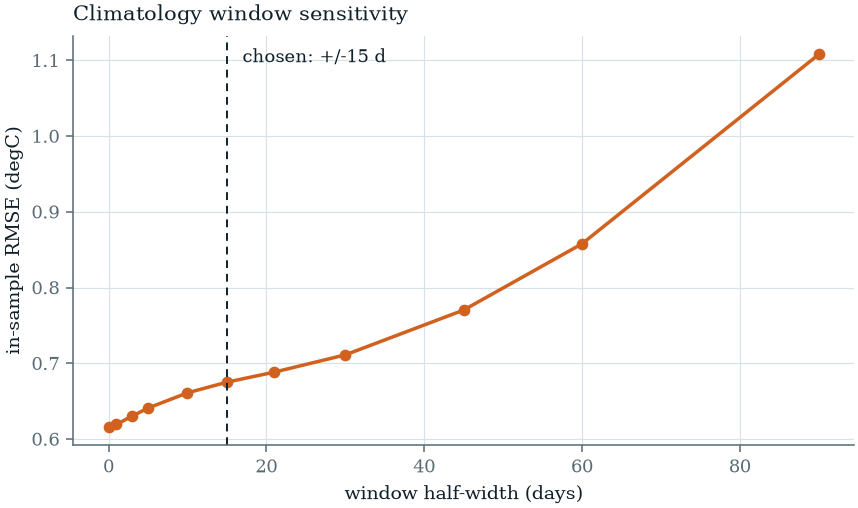

,window_days,rmse,scored
0,0,0.616077,18984
1,1,0.619309,18984
2,3,0.630284,18984
3,5,0.640873,18984
4,10,0.660979,18984
5,15,0.675062,18984
6,21,0.688320,18984
7,30,0.711099,18984
8,45,0.770258,18984
9,60,0.857757,18984


In [4]:
rows = []
for window in [0, 1, 3, 5, 10, 15, 21, 30, 45, 60, 90]:
    fit = fit_climatology(tidy["timestamp"], tidy["value"], tidy["site"],
                          window_days=window)
    pred = apply_climatology(fit, tidy["timestamp"], tidy["site"])
    ok = np.isfinite(pred)
    rmse = float(np.sqrt(np.mean((pred[ok] - tidy["value"].to_numpy()[ok]) ** 2)))
    rows.append({"window_days": window, "rmse": rmse, "scored": int(ok.sum())})
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(sweep["window_days"], sweep["rmse"], marker="o", color=mv.CLIMATOLOGY)
ax.axvline(15, color=mv.INK, linewidth=1.0, linestyle=(0, (4, 3)))
ax.annotate("chosen: +/-15 d", (15, sweep["rmse"].max()), xytext=(8, -4),
            textcoords="offset points", fontsize=9, color=mv.INK)
ax.set(xlabel="window half-width (days)", ylabel="in-sample RMSE (degC)",
       title="Climatology window sensitivity")
mv.save(fig, "03_window_sweep")
plt.show()
sweep

### The circular mean

Wave direction is a bearing: 359° and 1° are two degrees apart, but their
arithmetic mean is 180° — pointing exactly the wrong way. The climatology uses
$\operatorname{atan2}$ of the mean sine and cosine instead.

In [5]:
dates = pd.date_range("2024-01-01", periods=400, freq="D")
alternating = pd.Series(np.where(np.arange(400) % 2 == 0, 359.0, 1.0))
site_label = pd.Series(["demo"] * 400)

circular = fit_climatology(pd.Series(dates), alternating, site_label, circular=True)
linear   = fit_climatology(pd.Series(dates), alternating, site_label, circular=False)

# Summarise the fitted curves on the circle, not on the number line. The
# circular curve returns values modulo 360, so it lands near 0 *or* near
# 359.99 -- and a plain mean of those two is 180, which would make a correct
# circular fit look exactly as wrong as a broken one. Wrap to (-180, 180]
# first. This is the same trap the baseline itself exists to avoid.
def circular_mean_deg(values):
    radians = np.deg2rad(np.asarray(values, dtype="float64"))
    return float(np.rad2deg(np.arctan2(np.nanmean(np.sin(radians)),
                                       np.nanmean(np.cos(radians)))))

c = circular_mean_deg(circular.curves["demo"])
l = float(np.nanmean(linear.curves["demo"]))

print("values alternate between 359 deg and 1 deg -> true mean direction is 0 deg")
print(f"  circular fit   : {c:6.1f} deg   <- correct")
print(f"  arithmetic fit : {l:6.1f} deg   <- points the opposite way")
assert abs(((c + 180) % 360) - 180) < 1.0, "circular fit should recover ~0 deg"
assert abs(l - 180) < 5.0, "arithmetic fit should land near 180 deg"

values alternate between 359 deg and 1 deg -> true mean direction is 0 deg
  circular fit   :    0.0 deg   <- correct
  arithmetic fit :  180.0 deg   <- points the opposite way


### Where it is fitted — the leakage control

The climatology is refitted **inside every cross-validation fold, on that
fold's training rows only**. Fitting it once over the whole record leaks the
evaluation period into the baseline's own definition.

That error flatters the *baseline* and understates the *model* — an error in
the "safe" direction, which is exactly why it is easy to leave in place. The
cell below measures how large it is.

In [6]:
cut = tidy["timestamp"].quantile(0.8)
train = tidy[tidy["timestamp"] <= cut]
test  = tidy[tidy["timestamp"] >  cut]

honest = fit_climatology(train["timestamp"], train["value"], train["site"],
                         latitudes=train["latitude"], longitudes=train["longitude"])
leaked = fit_climatology(tidy["timestamp"], tidy["value"], tidy["site"],
                         latitudes=tidy["latitude"], longitudes=tidy["longitude"])

truth = test["value"].to_numpy(dtype="float64")
def score(fit):
    p = apply_climatology(fit, test["timestamp"], test["site"])
    ok = np.isfinite(p)
    return float(np.sqrt(np.mean((p[ok] - truth[ok]) ** 2)))

r_honest, r_leaked = score(honest), score(leaked)
print(f"climatology fitted on train only : RMSE {r_honest:.4f}   <- what we report")
print(f"climatology fitted on everything : RMSE {r_leaked:.4f}   <- leaked")
print(f"the leak makes the baseline look {100 * (1 - r_leaked / r_honest):.1f}% better,")
print("which would make the model look correspondingly worse.")

climatology fitted on train only : RMSE 1.2620   <- what we report
climatology fitted on everything : RMSE 0.8527   <- leaked
the leak makes the baseline look 32.4% better,
which would make the model look correspondingly worse.


## The model

One LightGBM regressor per (variable, horizon), fitted across **all 24 sites
jointly** with latitude, longitude, ocean depth and basin as features. Pooling
is what lets the framework score an arbitrary coordinate rather than only the
sites it saw — the assumption notebook 04 tests directly.

Hyperparameters are fixed across every variable and horizon. No per-variable
tuning was done, deliberately: tuning would confound the cross-variable
comparison the study exists to make.

In [7]:
pd.DataFrame([config.model_for(VARIABLE).to_lightgbm_params()]).T.rename(columns={0: "value"})

,value
n_estimators,400.00
learning_rate,0.05
num_leaves,31.00
max_depth,-1.00
min_child_samples,20.00
subsample,0.80
subsample_freq,1.00
colsample_bytree,0.80
reg_alpha,0.00
reg_lambda,1.00


## Skill score

$$S_r = 1 - \frac{\mathrm{RMSE}_{\text{model}}^2}{\mathrm{RMSE}_r^2}$$

$S_r > 0$ beats reference $r$; $S_r = 0$ is parity; $S_r < 0$ means the
reference is better and the model should not be deployed. We report $S$ against
**both** references for every model.

## End-to-end: one variable, four horizons, three predictors

A compact reproduction of the study's first experiment on a single variable,
using the real pooled frame, the real rolling-origin CV, and the real
climatology — refitted inside each fold.

In [8]:
variable = resolve(VARIABLE, config)
features_cfg = config.features_for(VARIABLE)
sites_meta = mv.load_sites().set_index("site")

def pooled_frame(horizon):
    parts = []
    for site in panel.columns:
        one = series[(series["variable"] == VARIABLE) & (series["site"] == site)]
        wide = one.pivot_table(index="timestamp", columns="field", values="value",
                               observed=True).reset_index()
        m = build_features(wide, variable, features_cfg,
                           latitude=float(sites_meta.loc[site, "latitude"]),
                           longitude=float(sites_meta.loc[site, "longitude"]),
                           horizon=horizon)
        f = m.frame.dropna(subset=[TARGET, TARGET_ANCHOR]).copy()
        f["site"] = site
        parts.append(f)
        cols, cats = m.feature_columns, m.categorical_columns
    out = pd.concat(parts, ignore_index=True).sort_values("timestamp").reset_index(drop=True)
    return out, cols, cats

pooled, feature_columns, categorical_columns = pooled_frame(7)
print(f"pooled: {len(pooled):,} rows across {pooled['site'].nunique()} sites")

pooled: 18,816 rows across 24 sites


In [9]:
from lightgbm import LGBMRegressor

def run(horizon):
    frame, cols, cats = pooled_frame(horizon)
    X = frame[cols]
    y = frame[TARGET]
    anchor = frame[TARGET_ANCHOR]

    def fit_predict(X_tr, y_tr, X_te):
        m = LGBMRegressor(**config.model_for(VARIABLE).to_lightgbm_params())
        a_tr = anchor.loc[y_tr.index].to_numpy(dtype="float64")
        m.fit(X_tr, y_tr.to_numpy(dtype="float64") - a_tr,
              categorical_feature=[c for c in cats if c in X_tr.columns])
        return np.asarray(m.predict(X_te), dtype="float64") + \
               anchor.loc[X_te.index].to_numpy(dtype="float64")

    def climatology_fold(train_idx, test_idx):
        tr, te = frame.iloc[train_idx], frame.iloc[test_idx]
        fit = fit_climatology(tr["timestamp"], tr[TARGET], tr["site"],
                              latitudes=tr["latitude"], longitudes=tr["longitude"],
                              window_days=15)
        return apply_climatology(fit, te["timestamp"], te["site"],
                                 latitudes=te["latitude"], longitudes=te["longitude"])

    result = cross_validate(
        X, y, frame["timestamp"], fit_predict, horizon_steps=horizon,
        config=config.defaults.validation, persistence=anchor,
        climatology_fit=climatology_fold,
    )
    return result.metrics

rows = []
for h in [1, 3, 7, 30]:
    m = run(h)
    rows.append({"horizon": h, "rmse": m["rmse"],
                 "persistence_rmse": m["persistence_rmse"],
                 "climatology_rmse": m["climatology_rmse"],
                 "skill_vs_persistence": m["skill_score"],
                 "skill_vs_climatology": m["skill_vs_climatology"]})
    print(f"h={h:<3} S_pers={m['skill_score']:+.3f}  S_clim={m['skill_vs_climatology']:+.3f}")

results = pd.DataFrame(rows)
results.round(4)

h=1   S_pers=+0.068  S_clim=+0.958


h=3   S_pers=+0.026  S_clim=+0.831


h=7   S_pers=+0.142  S_clim=+0.642


h=30  S_pers=+0.427  S_clim=+0.121


,horizon,rmse,persistence_rmse,climatology_rmse,skill_vs_persistence,skill_vs_climatology
0,1,0.2115,0.2191,1.0256,0.0683,0.9580
1,3,0.4524,0.4583,1.0987,0.0257,0.8307
2,7,0.6387,0.6897,1.0585,0.1423,0.6424
3,30,1.0522,1.3906,1.0663,0.4275,0.1212


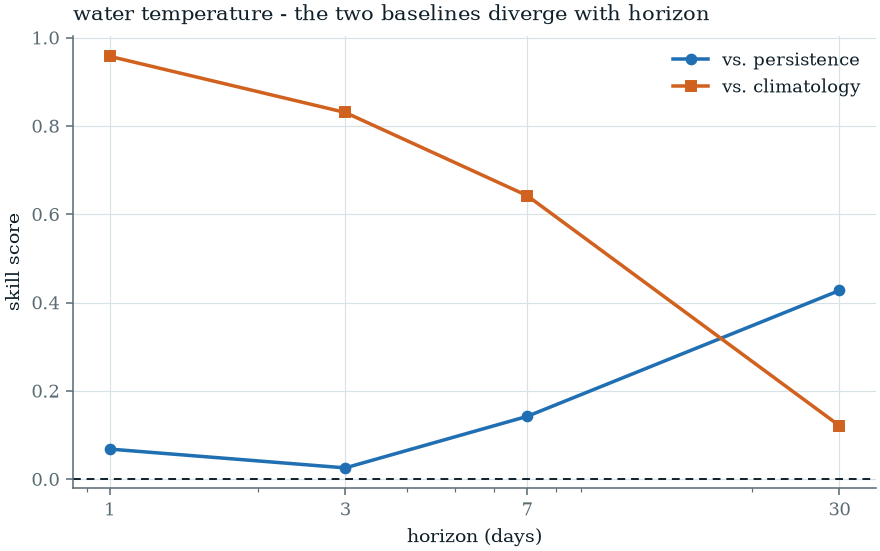

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(results["horizon"], results["skill_vs_persistence"], marker="o",
        color=mv.PERSISTENCE, label="vs. persistence")
ax.plot(results["horizon"], results["skill_vs_climatology"], marker="s",
        color=mv.CLIMATOLOGY, label="vs. climatology")
ax.axhline(0, color=mv.INK, linewidth=1.0, linestyle=(0, (4, 3)))
ax.set_xscale("log"); ax.set_xticks([1, 3, 7, 30])
ax.set_xticklabels(["1", "3", "7", "30"])
ax.set(xlabel="horizon (days)", ylabel="skill score",
       title=f"{mv.pretty(VARIABLE)} - the two baselines diverge with horizon")
ax.legend()
mv.save(fig, "03_two_baselines")
plt.show()

The two curves move apart. Persistence becomes easier to beat as the
horizon grows; climatology becomes *harder*, because the seasonal cycle is an
increasing share of what remains predictable at all.

Notebook 04 shows this holds across all 13 variables — and that for some of
them the climatology curve crosses zero, meaning the model is beaten by the
seasonal average while still comfortably beating persistence.

## Takeaways

1. **Persistence needs no fit** and is the delta target's anchor, so a model
   predicting zero change *is* persistence.
2. **The climatology window is a real parameter.** Too narrow is noise, too wide
   erases the season; ±15 days is chosen at the strongest point of the curve,
   which is the conservative choice for this argument.
3. **Bearings need a circular mean.** The arithmetic mean of 359° and 1° is
   180° — the opposite direction.
4. **Fitting the baseline on the evaluation period flatters it**, measurably,
   and in the direction that would understate the model. It is refitted inside
   every fold.
5. **Skill is reported against both references**, always.

Next: **04 — full results and spatial transfer**.